In [76]:
# Retail Sales EDA Project

Problem Statement :

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify customer purchasing patterns, product performance, and sales trends. The analysis aims to uncover meaningful business insights related to customer demographics, product categories, and revenue generation, helping businesses make data-driven decisions to improve sales and customer engagement.

In [78]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [79]:
## Import Libraries


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
## Load Dataset


In [82]:
df = pd.read_csv("retail_sales_dataset.csv")

In [83]:
## Data Cleaning


In [84]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [85]:
df.shape

(1000, 9)

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [87]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [88]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

df.duplicated().sum()

In [90]:
df.drop_duplicates(inplace=True)

In [91]:
df.columns = df.columns.str.strip()

In [92]:
df["Total Amount"].sum()

456000

In [93]:
## Exploratory Data Analysis


In [94]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [95]:
## Visualizations


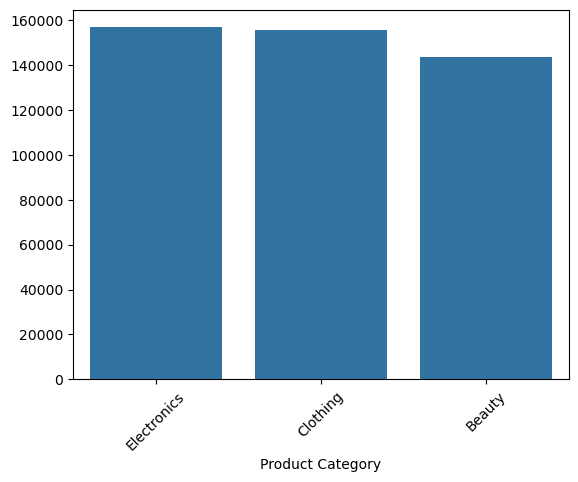

In [96]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

sns.barplot(x=category_sales.index,
            y=category_sales.values)

plt.xticks(rotation=45)

plt.savefig("sales_by_category.png")

plt.show()

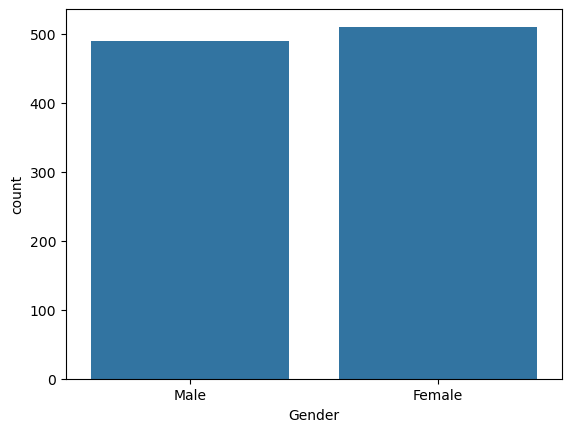

In [97]:
sns.countplot(x='Gender', data=df)
plt.show()

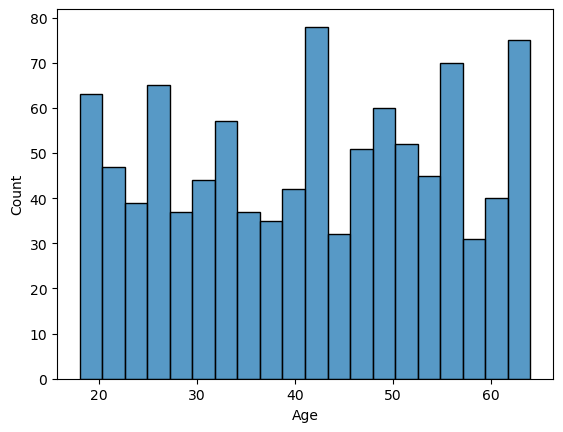

In [98]:
sns.histplot(df['Age'], bins=20)

plt.savefig("age_distribution.png")

plt.show()

# Insight

The customer age distribution is fairly spread across different age groups, with higher concentration observed between ages 40–60. 
This indicates that middle-aged customers contribute significantly to retail purchases.

In [100]:
df["Age Group"] = pd.cut(df["Age"],
                         bins=[0,18,25,35,50,100],
                         labels=["Teen","Young Adult","Adult","Middle Age","Senior"])

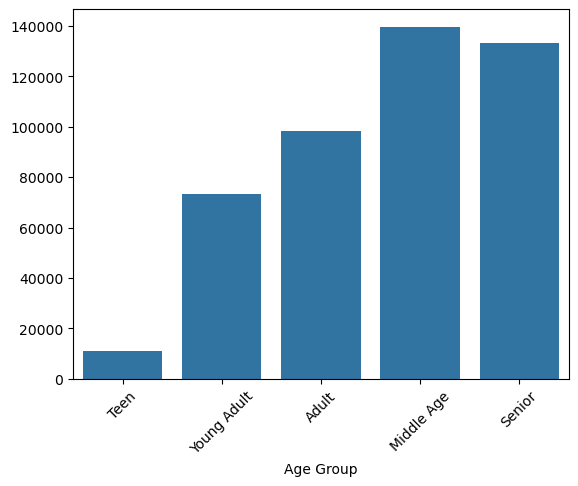

In [101]:
age_sales = df.groupby("Age Group", observed=False)["Total Amount"].sum()

sns.barplot(x=age_sales.index,
            y=age_sales.values)

plt.xticks(rotation=45)

plt.savefig("age_group_sales.png")

plt.show()

# Insight

Middle-aged and adult customers contribute the highest share of total sales, indicating stronger purchasing behavior among these age groups.

In [103]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

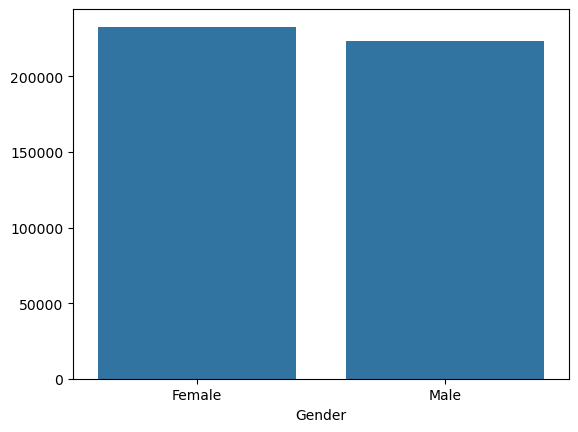

In [104]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

sns.barplot(x=gender_sales.index,
            y=gender_sales.values)

plt.savefig("gender_wise_sales.png")

plt.show()

# Insight

The analysis shows a difference in purchasing behavior between male and female customers. 
The gender contributing higher sales can be targeted for personalized marketing strategies.

In [106]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

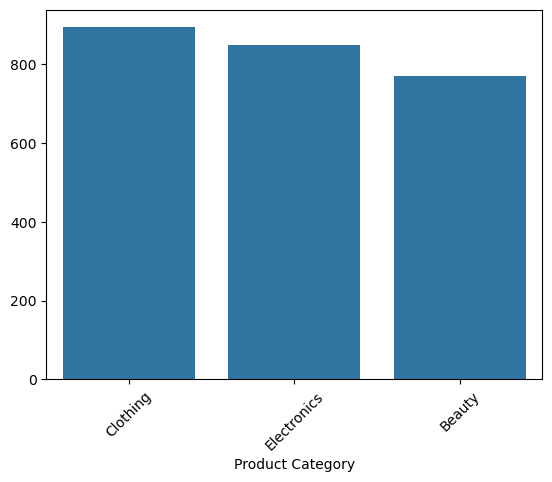

In [107]:
top_products = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

sns.barplot(x=top_products.index,
            y=top_products.values)

plt.xticks(rotation=45)

plt.savefig("top_selling_products.png")

plt.show()

# Insight

Certain product categories generate significantly higher revenue, indicating strong customer demand and better sales performance in those categories.

In [109]:
top_products = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

top_products

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

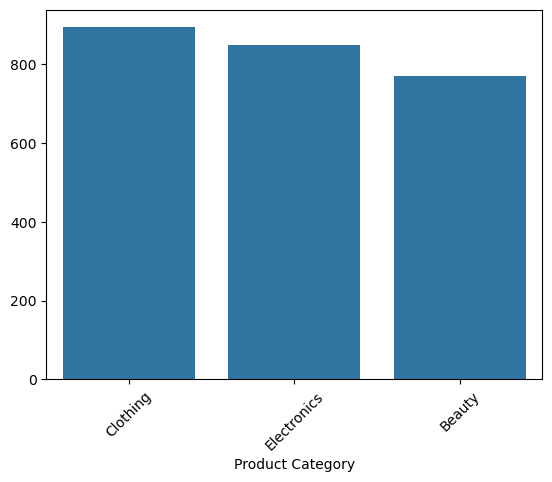

In [110]:
sns.barplot(x=top_products.index,
            y=top_products.values)

plt.xticks(rotation=45)
plt.show()

# Insight

Some product categories have significantly higher purchase quantities, showing strong customer demand and faster inventory movement.

In [112]:
average_order = df["Total Amount"].mean()

average_order

456.0

## Business Insights
- Certain product categories generated the highest revenue.
- Middle-aged customers contributed significantly to sales.
- Customer purchasing behavior varied across genders.
- High-demand categories showed stronger sales performance.
- Average order value indicated healthy customer spending patterns.

# Recommendations
- Focus marketing campaigns on high-performing product categories to maximize revenue.
- Target middle-aged and adult customers with personalized offers and loyalty programs.
- Improve inventory management for fast-selling products to avoid stock shortages.
- Analyze low-performing categories and introduce promotional strategies to improve sales.
- Use customer demographic insights to design better marketing and sales strategies.


# Conclusion
This Exploratory Data Analysis (EDA) project provided valuable insights into customer purchasing behavior, product performance, and sales trends within the retail dataset. The analysis identified key revenue-generating categories, important customer demographics, and purchasing patterns. These insights can help businesses make data-driven decisions to improve sales performance, customer engagement, and overall business strategy.

In [145]:
import os
os.getcwd()

'C:\\Users\\himan'